# ChemNet Projections for Encoder 1234e1e2 weighted

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

def plot_chemnet_pca(bin_val=1, threshold_val=0.1, 
                     include_super_test=True, include_regular_test=True, 
                     include_true_chemnet=True, include_training=True,
                     color_by_smiles=True, figsize=(12, 8), max_spectra_per_chemical=10, max_smiles_per_set=100):
    """
    Plot 2D PCA projections of chemnet embeddings with appropriate markers for dataset types
    
    Parameters:
    - bin_val, threshold_val: Parameters to select specific model outputs
    - include_super_test: Include super test chemicals (circles)
    - include_regular_test: Include regular test chemicals (squares)
    - include_true_chemnet: Include true ChemNet embeddings (x markers)
    - include_training: Include training spectra (triangles) - uses train==1 from dataframes
    - color_by_smiles: Color points by SMILES strings, but do not include in legend
    - figsize: Figure size tuple
    - max_spectra_per_chemical: Maximum number of spectra to plot per SMILES
    - max_smiles_per_set: Maximum number of SMILES to include per dataset type
    """
    
    base_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data"
    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')

    # Initialize lists to store all data
    all_embeddings = []
    all_smiles = []
    all_dataset_types = []
    all_markers = []
    
    embedding_dim = None
    selected_smiles = set()  # Track selected SMILES across all datasets
    regular_test_smiles = set()  # Track SMILES from regular test

    def pad_or_truncate(embeddings, target_dim):
        if embeddings.shape[1] < target_dim:
            return np.hstack([embeddings, np.zeros((embeddings.shape[0], target_dim - embeddings.shape[1]))])
        elif embeddings.shape[1] > target_dim:
            return embeddings[:, :target_dim]
        return embeddings

    def sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_per_smiles):
        """Limit the number of spectra per SMILES."""
        selected_rows = []
        for smile in df[smiles_col].unique():
            smile_rows = df[df[smiles_col] == smile]
            if len(smile_rows) > max_per_smiles:
                selected_rows.extend(smile_rows.sample(max_per_smiles).index)
            else:
                selected_rows.extend(smile_rows.index)
        return df.loc[selected_rows]

    def sample_smiles(df, smiles_col, max_smiles, embedding_cols, max_per_smiles):
        """Limit the number of unique SMILES and apply spectra size restriction."""
        unique_smiles = pd.unique(df[smiles_col])
        if len(unique_smiles) > max_smiles:
            selected_smiles_subset = np.random.choice(unique_smiles, max_smiles, replace=False)
            df = df[df[smiles_col].isin(selected_smiles_subset)]
        
        return sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_per_smiles)

    def load_and_process_data(file_path, dataset_label, marker, smiles_col="SMILES_spectra", 
                              track_smiles=False, filter_train=None, required_smiles=None):
        """
        Load and process data with optional train column filtering.
        
        Parameters:
        - filter_train: None (load all), 1 (load only train==1), 0 (load only train==0)
        - required_smiles: Set of SMILES that must be included (overrides sampling)
        """
        nonlocal embedding_dim, selected_smiles
        try:
            df = pd.read_parquet(file_path)
            
            # Filter by train column if specified
            if filter_train is not None and 'train' in df.columns:
                df = df[df['train'] == filter_train]
                print(f"Filtered to train=={filter_train}, remaining samples: {len(df)}")
            
            # If required_smiles is provided, ensure those SMILES are included
            if required_smiles is not None and len(required_smiles) > 0:
                # Filter to only include required SMILES
                df = df[df[smiles_col].isin(required_smiles)]
                print(f"Filtered to required SMILES, remaining samples: {len(df)}")
            
            embedding_cols = [col for col in df.columns if col.startswith('cond_emb_') 
                              and 'morgan' not in col.lower() and 'filtered' not in col.lower()]
            
            # Only apply sampling if no required_smiles constraint
            if required_smiles is None:
                df = sample_smiles(df, smiles_col, max_smiles_per_set, embedding_cols, max_spectra_per_chemical)
            else:
                # Still limit spectra per chemical even with required SMILES
                df = sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_spectra_per_chemical)
            
            if not embedding_cols or len(df) == 0:
                return set()
            
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values

            if track_smiles:
                selected_smiles.update(smiles)  # Add SMILES from this dataset to the shared set
            
            if embedding_dim is None:
                embedding_dim = embeddings.shape[1]
            
            embeddings = pad_or_truncate(embeddings, embedding_dim)
            
            all_embeddings.extend(embeddings)
            all_smiles.extend(smiles)
            all_dataset_types.extend([dataset_label] * len(smiles))
            all_markers.extend([marker] * len(smiles))
            print(f"Loaded {len(smiles)} samples for {dataset_label}.")
            
            return set(smiles)

        except FileNotFoundError:
            print(f"File not found: {file_path}")
            return set()
        except Exception as e:
            print(f"Error processing {dataset_label}: {e}")
            return set()

    def load_and_process_chemnet_data(file_path, dataset_label, marker, smiles_col="SMILES_spectra"):
        """Process ChemNet embeddings restricted to previously selected SMILES."""
        nonlocal embedding_dim, selected_smiles
        try:
            df = pd.read_parquet(file_path)
            
            embedding_cols = [col for col in df.columns if col.startswith('Embedding Float ')]
            embedding_cols.sort(key=lambda x: int(x.split()[-1]))
            
            # Restrict to SMILES selected from other datasets
            df = df[df[smiles_col].isin(selected_smiles)]
            df = sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_spectra_per_chemical)
            
            if not embedding_cols:
                return
            
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            
            if embedding_dim is None:
                embedding_dim = embeddings.shape[1]
            
            embeddings = pad_or_truncate(embeddings, embedding_dim)
            
            all_embeddings.extend(embeddings)
            all_smiles.extend(smiles)
            all_dataset_types.extend([dataset_label] * len(smiles))
            all_markers.extend([marker] * len(smiles))
            print(f"Loaded {len(smiles)} samples for {dataset_label}.")

        except FileNotFoundError:
            print(f"File not found: {file_path}")
        except Exception as e:
            print(f"Error processing {dataset_label}: {e}")

    # Load datasets in sequence
    # Regular test file: load test data (train==0) if include_regular_test, and training data (train==1) if include_training
    regular_file = f"{base_folder}/cond_enc_1234e1e2_classification_df6/cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    
    # Step 1: Load regular test data first to identify which SMILES are in the test set
    if include_regular_test:
        regular_test_smiles = load_and_process_data(
            regular_file, "Regular Test", 's', track_smiles=True, filter_train=0
        )
    
    # Step 2: Load training data - if regular test was loaded, ensure those SMILES are included
    if include_training:
        if include_regular_test and len(regular_test_smiles) > 0:
            # Force training to include the same SMILES as regular test
            load_and_process_data(
                regular_file, "Training", '^', track_smiles=True, 
                filter_train=1, required_smiles=regular_test_smiles
            )
        else:
            # No constraint, just sample normally
            load_and_process_data(
                regular_file, "Training", '^', track_smiles=True, filter_train=1
            )
    
    # Step 3: Load super test (independent from regular test/training)
    if include_super_test:
        super_file = f"{base_folder}/cond_enc_1234e1e2_classification_df6_super_test/super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
        load_and_process_data(super_file, "Super Test", 'o', track_smiles=True)
    
    # Step 4: Load true ChemNet embeddings
    if include_true_chemnet:
        chemnet_file = f"{base_folder}/df6_chemnet.parquet"
        load_and_process_chemnet_data(chemnet_file, "True ChemNet", 'x')

    if not all_embeddings:
        print("No data loaded! Please verify file paths.")
        return
    
    embeddings_matrix = np.array(all_embeddings)
    smiles_array = np.array(all_smiles)
    dataset_types_array = np.array(all_dataset_types)
    markers_array = np.array(all_markers)

    print(f"Total samples loaded: {len(embeddings_matrix)}")
    
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings_matrix)
    
    pca = PCA(n_components=2, random_state=42)
    embeddings_2d = pca.fit_transform(embeddings_scaled)
    print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

    if color_by_smiles:
        unique_smiles = list(set(smiles_array))
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_smiles)))
        smiles_to_color = {smile: color for smile, color in zip(unique_smiles, colors)}
        point_colors = np.array([smiles_to_color[smiles] for smiles in smiles_array])
    else:
        point_colors = 'black'

    fig, ax = plt.subplots(figsize=figsize)

    for dataset_type in set(dataset_types_array):
        mask = dataset_types_array == dataset_type
        marker = markers_array[mask][0]
        subset_colors = point_colors[mask] if color_by_smiles else 'black'
        
        specific_alpha = 1.0 if dataset_type == "True ChemNet" else 0.7
        
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=subset_colors,
            marker=marker,
            s=50,
            alpha=specific_alpha,
            label=dataset_type
        )

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f} variance explained)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f} variance explained)')
    ax.set_title(f'2D PCA of ChemNet Embeddings\n(bin={bin_val}, threshold={threshold_val})')

    marker_map = {
        'Regular Test': 's',
        'Super Test': 'o',
        'True ChemNet': 'x',
        'Training': '^'
    }
    legend_elements = [
        Line2D([0], [0], marker=marker_map[label], color='w', markersize=8, markeredgecolor='black',
               label=label, markerfacecolor='black')  # Both marker shape and label
        for label in marker_map if label in set(dataset_types_array)
    ]
    ax.legend(handles=legend_elements, title='Dataset Types', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

Filtered to train==0, remaining samples: 7222
Loaded 39 samples for Regular Test.
Filtered to train==1, remaining samples: 7637
Filtered to required SMILES, remaining samples: 69
Loaded 40 samples for Training.
Loaded 49 samples for Super Test.
Loaded 20 samples for True ChemNet.
Total samples loaded: 148
PCA explained variance ratio: [0.12163864 0.11300351]


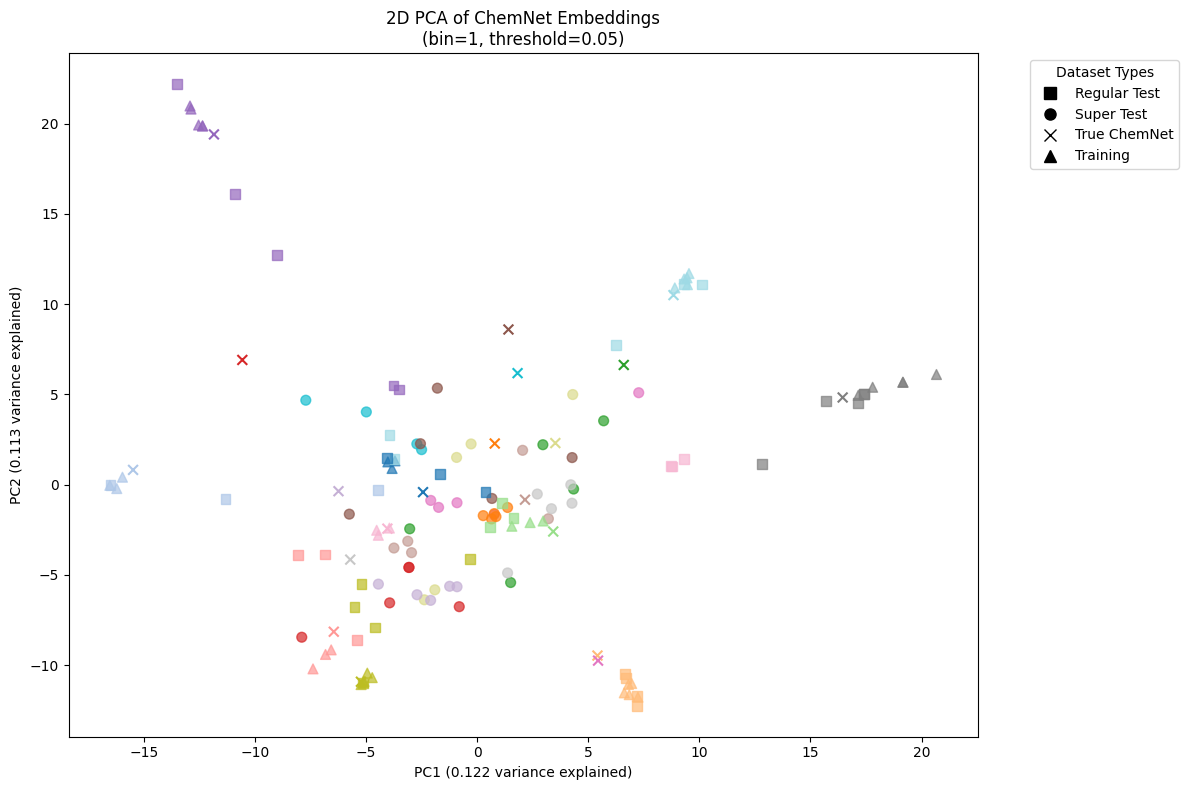

In [80]:
plot_chemnet_pca(
    bin_val=1,                              # The bin value used for naming outputs (default: 1)
    threshold_val=0.05,                      # The threshold value for naming outputs (default: 0.1)
    include_super_test=True,                # Whether to include super test dataset (default: True)
    include_regular_test=True,              # Whether to include regular test dataset (default: True)
    include_true_chemnet=True,              # Whether to include True ChemNet embeddings (default: True)
    include_training=True,                  # Whether to include training dataset (default: True)
    color_by_smiles=True,                   # Whether to color points by SMILES (default: True)
    figsize=(12, 8),                        # Size of the figure (default: (12, 8))
    max_spectra_per_chemical=5,            # Maximum spectra per chemical plotted (default: 10)
    max_smiles_per_set=10                  # Maximum number of SMILES per dataset (default: 100)
)

# ChemNet Projections with super tests made black for topology investigation

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

def plot_chemnet_pca_multi(bin_val=1, threshold_val=0.1, 
                     include_super_test=True, include_regular_test=True, 
                     include_true_chemnet=True, include_training=True,
                     color_by_smiles=True, super_test_black=False,
                     figsize=(20, 10), max_spectra_per_chemical=10, max_smiles_per_set=100,
                     n_plots=8, random_seed=42):
    """
    Plot 2D PCA projections of chemnet embeddings with appropriate markers for dataset types
    Creates multiple subplots with different random selections of regular test/train SMILES
    
    Parameters:
    - bin_val, threshold_val: Parameters to select specific model outputs
    - include_super_test: Include super test chemicals (circles)
    - include_regular_test: Include regular test chemicals (squares)
    - include_true_chemnet: Include true ChemNet embeddings (x markers)
    - include_training: Include training spectra (triangles) - uses train==1 from dataframes
    - color_by_smiles: Color points by SMILES strings, but do not include in legend
    - super_test_black: If True, color all super test points black regardless of SMILES
    - figsize: Figure size tuple for the entire figure
    - max_spectra_per_chemical: Maximum number of spectra to plot per SMILES
    - max_smiles_per_set: Maximum number of SMILES to include per dataset type (for regular test/train)
    - n_plots: Number of subplots to create (default: 8)
    - random_seed: Base random seed for reproducibility
    """
    
    base_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data"
    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')

    regular_file = f"{base_folder}/cond_enc_1234e1e2_classification_df6/cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    super_file = f"{base_folder}/cond_enc_1234e1e2_classification_df6_super_test/super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
    chemnet_file = f"{base_folder}/df6_chemnet.parquet"

    def pad_or_truncate(embeddings, target_dim):
        if embeddings.shape[1] < target_dim:
            return np.hstack([embeddings, np.zeros((embeddings.shape[0], target_dim - embeddings.shape[1]))])
        elif embeddings.shape[1] > target_dim:
            return embeddings[:, :target_dim]
        return embeddings

    def sample_spectra_per_chemical(df, smiles_col, max_per_smiles):
        """Limit the number of spectra per SMILES."""
        selected_rows = []
        for smile in df[smiles_col].unique():
            smile_rows = df[df[smiles_col] == smile]
            if len(smile_rows) > max_per_smiles:
                selected_rows.extend(smile_rows.sample(max_per_smiles).index)
            else:
                selected_rows.extend(smile_rows.index)
        return df.loc[selected_rows]

    def load_all_super_test_data(file_path, smiles_col="SMILES_spectra"):
        """Load ALL super test data (no sampling by SMILES, but limit spectra per SMILES)"""
        try:
            df = pd.read_parquet(file_path)
            embedding_cols = [col for col in df.columns if col.startswith('cond_emb_') 
                              and 'morgan' not in col.lower() and 'filtered' not in col.lower()]
            
            # Sample spectra per chemical but include ALL SMILES
            df = sample_spectra_per_chemical(df, smiles_col, max_spectra_per_chemical)
            
            if not embedding_cols or len(df) == 0:
                return None, None, None
            
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            
            return embeddings, smiles, embedding_cols
        except Exception as e:
            print(f"Error loading super test data: {e}")
            return None, None, None

    def load_and_sample_regular_data(file_path, filter_train, max_smiles, smiles_col="SMILES_spectra", 
                                      required_smiles=None, seed=None):
        """Load and sample regular test or training data"""
        try:
            df = pd.read_parquet(file_path)
            
            # Filter by train column
            if 'train' in df.columns:
                df = df[df['train'] == filter_train]
            
            embedding_cols = [col for col in df.columns if col.startswith('cond_emb_') 
                              and 'morgan' not in col.lower() and 'filtered' not in col.lower()]
            
            if not embedding_cols or len(df) == 0:
                return None, None, set()
            
            # If required_smiles is provided, filter to those
            if required_smiles is not None and len(required_smiles) > 0:
                df = df[df[smiles_col].isin(required_smiles)]
            else:
                # Sample SMILES
                unique_smiles = pd.unique(df[smiles_col])
                if len(unique_smiles) > max_smiles:
                    if seed is not None:
                        np.random.seed(seed)
                    selected_smiles_subset = np.random.choice(unique_smiles, max_smiles, replace=False)
                    df = df[df[smiles_col].isin(selected_smiles_subset)]
            
            # Sample spectra per chemical
            df = sample_spectra_per_chemical(df, smiles_col, max_spectra_per_chemical)
            
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            
            return embeddings, smiles, set(smiles)
        except Exception as e:
            print(f"Error loading regular data: {e}")
            return None, None, set()

    def load_chemnet_data(file_path, selected_smiles, smiles_col="SMILES_spectra"):
        """Load ChemNet embeddings for selected SMILES"""
        try:
            df = pd.read_parquet(file_path)
            
            embedding_cols = [col for col in df.columns if col.startswith('Embedding Float ')]
            embedding_cols.sort(key=lambda x: int(x.split()[-1]))
            
            # Restrict to selected SMILES
            df = df[df[smiles_col].isin(selected_smiles)]
            df = sample_spectra_per_chemical(df, smiles_col, max_spectra_per_chemical)
            
            if not embedding_cols or len(df) == 0:
                return None, None
            
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            
            return embeddings, smiles
        except Exception as e:
            print(f"Error loading ChemNet data: {e}")
            return None, None

    # Load super test data once (used in all subplots)
    super_test_embeddings = None
    super_test_smiles = None
    super_test_smiles_set = set()  # Track super test SMILES
    if include_super_test:
        super_test_embeddings, super_test_smiles, _ = load_all_super_test_data(super_file)
        if super_test_embeddings is not None:
            super_test_smiles_set = set(super_test_smiles)
            print(f"Loaded {len(super_test_smiles)} super test samples (all SMILES)")

    # Fit PCA on super test data (or all available data) to ensure consistent projection
    # First, determine embedding dimension and fit PCA
    embedding_dim = None
    scaler = None
    pca = None
    
    if super_test_embeddings is not None:
        embedding_dim = super_test_embeddings.shape[1]
        # Fit scaler and PCA on super test data
        scaler = StandardScaler()
        super_test_scaled = scaler.fit_transform(super_test_embeddings)
        pca = PCA(n_components=2, random_state=42)
        pca.fit(super_test_scaled)
        print(f"PCA fitted on super test data. Explained variance ratio: {pca.explained_variance_ratio_}")
    else:
        print("Warning: No super test data available to fit PCA. PCA will be fitted per subplot.")

    # Pre-compute super test projections
    super_test_2d = None
    if super_test_embeddings is not None and scaler is not None and pca is not None:
        super_test_scaled = scaler.transform(super_test_embeddings)
        super_test_2d = pca.transform(super_test_scaled)

    # Create figure with subplots
    n_rows = 2
    n_cols = n_plots // n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    # Generate each subplot
    for plot_idx in range(n_plots):
        ax = axes[plot_idx]
        seed = random_seed + plot_idx if random_seed is not None else None
        
        # Initialize lists for this subplot
        all_embeddings = []
        all_smiles = []
        all_dataset_types = []
        all_markers = []
        all_2d_projections = []  # Store pre-computed 2D projections
        selected_smiles_all = set()
        
        # Load regular test data with unique random sampling
        regular_test_smiles_set = set()
        if include_regular_test:
            reg_test_emb, reg_test_smiles, regular_test_smiles_set = load_and_sample_regular_data(
                regular_file, filter_train=0, max_smiles=max_smiles_per_set, seed=seed
            )
            if reg_test_emb is not None:
                if embedding_dim is None:
                    embedding_dim = reg_test_emb.shape[1]
                else:
                    reg_test_emb = pad_or_truncate(reg_test_emb, embedding_dim)
                all_embeddings.extend(reg_test_emb)
                all_smiles.extend(reg_test_smiles)
                all_dataset_types.extend(["Regular Test"] * len(reg_test_smiles))
                all_markers.extend(['s'] * len(reg_test_smiles))
                selected_smiles_all.update(reg_test_smiles)
        
        # Load training data matching regular test SMILES
        if include_training:
            train_emb, train_smiles, _ = load_and_sample_regular_data(
                regular_file, filter_train=1, max_smiles=max_smiles_per_set, 
                required_smiles=regular_test_smiles_set if include_regular_test else None, seed=seed
            )
            if train_emb is not None:
                if embedding_dim is None:
                    embedding_dim = train_emb.shape[1]
                else:
                    train_emb = pad_or_truncate(train_emb, embedding_dim)
                all_embeddings.extend(train_emb)
                all_smiles.extend(train_smiles)
                all_dataset_types.extend(["Training"] * len(train_smiles))
                all_markers.extend(['^'] * len(train_smiles))
                selected_smiles_all.update(train_smiles)
        
        # Add super test data (use pre-computed projections)
        if include_super_test and super_test_embeddings is not None and super_test_2d is not None:
            all_embeddings.extend(super_test_embeddings)
            all_smiles.extend(super_test_smiles)
            all_dataset_types.extend(["Super Test"] * len(super_test_smiles))
            all_markers.extend(['o'] * len(super_test_smiles))
            selected_smiles_all.update(super_test_smiles)
        
        # Load ChemNet data
        if include_true_chemnet:
            chemnet_emb, chemnet_smiles = load_chemnet_data(chemnet_file, selected_smiles_all)
            if chemnet_emb is not None:
                if embedding_dim is None:
                    embedding_dim = chemnet_emb.shape[1]
                else:
                    chemnet_emb = pad_or_truncate(chemnet_emb, embedding_dim)
                all_embeddings.extend(chemnet_emb)
                all_smiles.extend(chemnet_smiles)
                all_dataset_types.extend(["True ChemNet"] * len(chemnet_smiles))
                all_markers.extend(['x'] * len(chemnet_smiles))
        
        if not all_embeddings:
            print(f"No data loaded for subplot {plot_idx + 1}")
            continue
        
        # Convert to arrays
        embeddings_matrix = np.array(all_embeddings)
        smiles_array = np.array(all_smiles)
        dataset_types_array = np.array(all_dataset_types)
        markers_array = np.array(all_markers)
        
        # Apply the same PCA transformation to all data
        if scaler is not None and pca is not None:
            embeddings_scaled = scaler.transform(embeddings_matrix)
            embeddings_2d = pca.transform(embeddings_scaled)
        else:
            # Fallback: fit new PCA for this subplot
            scaler_local = StandardScaler()
            embeddings_scaled = scaler_local.fit_transform(embeddings_matrix)
            pca_local = PCA(n_components=2, random_state=42)
            embeddings_2d = pca_local.fit_transform(embeddings_scaled)
            pca = pca_local  # Use for variance display
        
        # Prepare colors
        if color_by_smiles:
            unique_smiles = list(set(smiles_array))
            colors = plt.cm.tab20(np.linspace(0, 1, len(unique_smiles)))
            smiles_to_color = {smile: color for smile, color in zip(unique_smiles, colors)}
            point_colors = np.array([smiles_to_color[smiles] for smiles in smiles_array])
            
            # Override super test colors to black if requested
            # This includes both Super Test embeddings AND True ChemNet embeddings for super test SMILES
            if super_test_black:
                super_test_mask = dataset_types_array == "Super Test"
                point_colors[super_test_mask] = [0, 0, 0, 1]  # Black
                
                # Also color True ChemNet embeddings black if they correspond to super test SMILES
                chemnet_mask = dataset_types_array == "True ChemNet"
                for i, (is_chemnet, smile) in enumerate(zip(chemnet_mask, smiles_array)):
                    if is_chemnet and smile in super_test_smiles_set:
                        point_colors[i] = [0, 0, 0, 1]  # Black
        else:
            point_colors = 'black'
        
        # Plot each dataset type
        for dataset_type in set(dataset_types_array):
            mask = dataset_types_array == dataset_type
            marker = markers_array[mask][0]
            subset_colors = point_colors[mask] if color_by_smiles else 'black'
            
            specific_alpha = 1.0 if dataset_type == "True ChemNet" else 0.7
            
            ax.scatter(
                embeddings_2d[mask, 0],
                embeddings_2d[mask, 1],
                c=subset_colors,
                marker=marker,
                s=50,
                alpha=specific_alpha,
                label=dataset_type
            )
        
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})', fontsize=8)
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})', fontsize=8)
        ax.set_title(f'Plot {plot_idx + 1}', fontsize=10)
        ax.tick_params(labelsize=7)
        
        # Add legend only to first subplot
        if plot_idx == 0:
            marker_map = {
                'Regular Test': 's',
                'Super Test': 'o',
                'True ChemNet': 'x',
                'Training': '^'
            }
            legend_elements = [
                Line2D([0], [0], marker=marker_map[label], color='w', markersize=8, 
                       markeredgecolor='black', label=label, markerfacecolor='black')
                for label in marker_map if label in set(dataset_types_array)
            ]
            ax.legend(handles=legend_elements, title='Dataset Types', 
                     fontsize=7, title_fontsize=8, loc='best')
    
    plt.suptitle(f'2D PCA of ChemNet Embeddings (bin={bin_val}, threshold={threshold_val})', 
                 fontsize=14, y=0.995)
    plt.tight_layout()
    plt.show()

Loaded 103 super test samples (all SMILES)
PCA fitted on super test data. Explained variance ratio: [0.12667325 0.09536375]


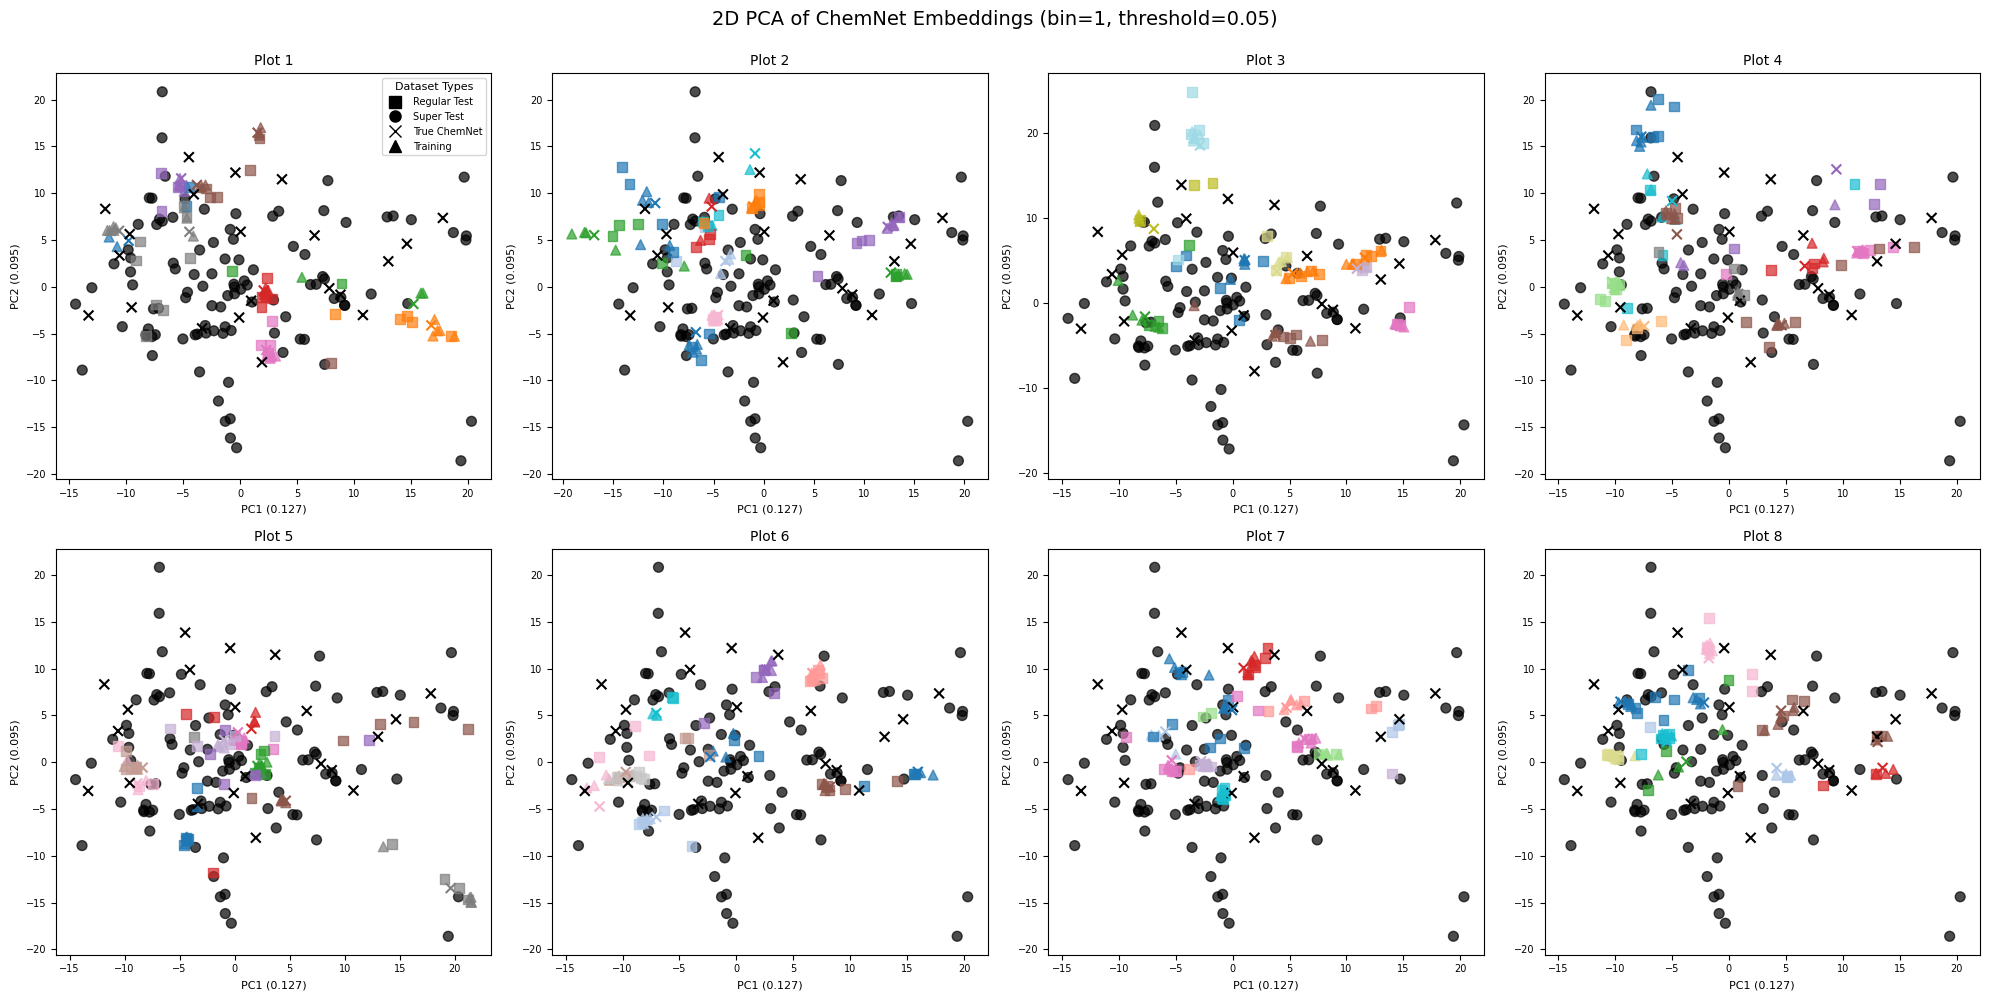

In [81]:
plot_chemnet_pca_multi(
    bin_val=1,
    threshold_val=0.05,
    include_super_test=True,
    include_regular_test=True,
    include_true_chemnet=True,
    include_training=True,
    color_by_smiles=True,
    super_test_black=True,  # Makes super test points all black
    figsize=(20, 10),
    max_spectra_per_chemical=5,
    max_smiles_per_set=10,
    n_plots=8,
    random_seed=42
)